# 00 - Data Preprocessing

This notebook preprocesses the raw BCI Competition IIIa GDF files and creates training/validation datasets.

## Prerequisites
- Raw GDF files placed in `data/raw/` directory (k3b.gdf, k6b.gdf, l1b.gdf)
- All required packages installed (see `requirements.txt`)
- Jupyter kernel restarted if configuration has been modified

## Overview
- Load raw GDF files (k3b.gdf, k6b.gdf, l1b.gdf)
- Apply bandpass filter (8-30 Hz for motor imagery)
- Apply notch filter (50 Hz for powerline noise)
- Extract epochs around motor imagery cues
- Split into train/validation sets (80/20)
- Save preprocessed data as NumPy arrays

## Event Mapping (Motor Imagery → Directional UI Control)
- **Event 769** (Left hand imagery) → Class 0 → **"left"**
- **Event 770** (Right hand imagery) → Class 1 → **"right"**
- **Event 771** (Foot imagery) → Class 2 → **"down"**
- **Event 772** (Tongue imagery) → Class 3 → **"up"**

*Note: Users imagine moving these body parts without actually moving. The model detects brain patterns and outputs directional commands for UI control.*

In [1]:
import sys
from pathlib import Path
import numpy as np
import yaml
import mne
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\soheil\Downloads\IOS_BCI_STUDIO\bci_ml_pipeline


## 1. Load Configuration

In [2]:
# Load configuration
config_path = PROJECT_ROOT / "configs" / "config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("Configuration loaded:")
print(f"  Subjects: {config['paths']['subjects']}")
print(f"  Sampling rate: {config['preprocessing']['sfreq']} Hz")
print(f"  Bandpass filter: {config['preprocessing']['bandpass']['low']}-{config['preprocessing']['bandpass']['high']} Hz")
print(f"  Notch filter: {config['preprocessing']['notch']['freq']} Hz")
print(f"  Epoch window: [{config['preprocessing']['epoch']['tmin']}, {config['preprocessing']['epoch']['tmax']}] seconds")
print(f"  Validation split: {config['preprocessing']['validation_split']}")

Configuration loaded:
  Subjects: ['k3b.gdf', 'k6b.gdf', 'l1b.gdf']
  Sampling rate: 250 Hz
  Bandpass filter: 8.0-30.0 Hz
  Notch filter: 50.0 Hz
  Epoch window: [-0.5, 3.5] seconds
  Validation split: 0.2


## 2. Check Raw Data Files

In [3]:
# Check if raw data files exist
raw_dir = PROJECT_ROOT / config['paths']['raw_data']
subject_files = config['paths']['subjects']

print(f"Checking for raw data files in: {raw_dir}\n")

all_files_exist = True
for subject_file in subject_files:
    file_path = raw_dir / subject_file
    if file_path.exists():
        file_size_mb = file_path.stat().st_size / (1024 * 1024)
        print(f"  [FOUND] {subject_file} ({file_size_mb:.2f} MB)")
    else:
        print(f"  [MISSING] {subject_file}")
        all_files_exist = False

if not all_files_exist:
    print("\n[ERROR] Some GDF files are missing.")
    print("Please download the BCI Competition IIIa dataset from:")
    print("https://www.bbci.de/competition/iii/")
    print(f"And place k3b.gdf, k6b.gdf, l1b.gdf in: {raw_dir}")
    raise FileNotFoundError("Raw data files not found")
else:
    print("\n[SUCCESS] All raw data files found")

Checking for raw data files in: C:\Users\soheil\Downloads\IOS_BCI_STUDIO\bci_ml_pipeline\data\raw

  [FOUND] k3b.gdf (112.96 MB)
  [FOUND] k6b.gdf (72.26 MB)
  [FOUND] l1b.gdf (72.52 MB)

[SUCCESS] All raw data files found


## 3. Define Preprocessing Functions

In [4]:
def load_gdf_file(file_path: Path) -> tuple:
    """
    Load a GDF file and extract raw EEG data.
    
    Returns:
        Tuple of (raw, events, event_id)
    """
    print(f"\nLoading {file_path.name}...")
    
    # Load raw GDF file
    raw = mne.io.read_raw_gdf(file_path, preload=True, verbose=False)
    
    # Get events from annotations
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    
    print(f"  Loaded {len(raw.ch_names)} channels, {raw.n_times} timepoints")
    print(f"  Sampling rate: {raw.info['sfreq']} Hz")
    print(f"  Duration: {raw.times[-1]:.2f} seconds")
    print(f"  Found {len(events)} events")
    
    return raw, events, event_id


def apply_filters(raw: mne.io.Raw, config: dict) -> mne.io.Raw:
    """
    Apply bandpass and notch filters to raw EEG data.
    """
    print("  Applying filters...")
    
    # Bandpass filter (8-30 Hz for motor imagery)
    raw.filter(
        l_freq=config['preprocessing']['bandpass']['low'],
        h_freq=config['preprocessing']['bandpass']['high'],
        fir_design='firwin',
        verbose=False
    )
    print(f"    Bandpass: {config['preprocessing']['bandpass']['low']}-"
          f"{config['preprocessing']['bandpass']['high']} Hz")
    
    # Notch filter (50 Hz powerline noise)
    raw.notch_filter(
        freqs=config['preprocessing']['notch']['freq'],
        verbose=False
    )
    print(f"    Notch: {config['preprocessing']['notch']['freq']} Hz")
    
    return raw


def extract_epochs(raw: mne.io.Raw, events: np.ndarray,
                   event_id: dict, config: dict) -> tuple:
    """
    Extract epochs from raw data based on event codes.

    Returns:
        Tuple of (epochs_data, labels)
    """
    print("  Extracting epochs...")

    # Find motor imagery events
    # In BCI Competition IIIa, events are named '769', '770', '771', '772'
    motor_imagery_events = {}
    code_to_class = {}  # Map MNE codes to our class indices
    
    for event_name, event_code in event_id.items():
        name_str = str(event_name)
        
        if '769' in name_str:
            motor_imagery_events[event_name] = event_code
            code_to_class[event_code] = 0  # left hand
        elif '770' in name_str:
            motor_imagery_events[event_name] = event_code
            code_to_class[event_code] = 1  # right hand
        elif '771' in name_str:
            motor_imagery_events[event_name] = event_code
            code_to_class[event_code] = 2  # foot
        elif '772' in name_str:
            motor_imagery_events[event_name] = event_code
            code_to_class[event_code] = 3  # tongue

    if not motor_imagery_events:
        print("    [ERROR] No motor imagery events (769-772) found")
        print(f"    Event names in file: {list(event_id.keys())}")
        raise ValueError("No motor imagery events found in data")

    print(f"    Motor imagery events found:")
    for event_name, event_code in motor_imagery_events.items():
        class_idx = code_to_class[event_code]
        class_name = config['preprocessing']['class_mapping'][class_idx]
        print(f"      '{event_name}' (code {event_code}) -> Class {class_idx} ({class_name})")

    # Create epochs using the MNE event codes (not remapped)
    tmin = config['preprocessing']['epoch']['tmin']
    tmax = config['preprocessing']['epoch']['tmax']
    baseline = tuple(config['preprocessing']['epoch']['baseline'])

    epochs = mne.Epochs(
        raw,
        events,
        event_id=motor_imagery_events,  # Use original MNE codes
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,
        verbose=False
    )

    # Get data and MNE's event codes
    epochs_data = epochs.get_data()  # Shape: (n_epochs, n_channels, n_times)
    
    # CRITICAL: Scale from Volts to microvolts (µV)
    # MNE loads GDF files in Volts, but neural networks need proper signal magnitude
    # Without this scaling, signals are too small (~1e-5) and the network produces identical outputs
    epochs_data = epochs_data * 1e6  # Convert V → µV
    print(f"    Data scaled to microvolts (range: {epochs_data.min():.2f} to {epochs_data.max():.2f} µV)")
    
    mne_labels = epochs.events[:, -1]  # MNE's event codes (3, 4, 5, 6)
    
    # Remap MNE codes to our class indices (0, 1, 2, 3)
    labels = np.array([code_to_class[code] for code in mne_labels])

    print(f"    Extracted {len(epochs_data)} epochs")
    print(f"    Shape: {epochs_data.shape}")
    print(f"    Time window: [{tmin}, {tmax}] seconds")

    # Print class distribution
    unique, counts = np.unique(labels, return_counts=True)
    class_names = config['preprocessing']['class_mapping']
    print(f"    Class distribution:")
    for cls, count in zip(unique, counts):
        print(f"      Class {cls} ({class_names[cls]}): {count} trials")

    return epochs_data, labels


def split_and_save(epochs_data: np.ndarray, labels: np.ndarray,
                   subject_id: str, output_dir: Path, config: dict):
    """
    Split data into train/val and save as NumPy arrays.
    """
    print("  Splitting and saving data...")
    
    # Create output directory
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Train/validation split
    val_split = config['preprocessing']['validation_split']
    random_seed = config['preprocessing']['random_seed']
    
    X_train, X_val, y_train, y_val = train_test_split(
        epochs_data,
        labels,
        test_size=val_split,
        random_state=random_seed,
        stratify=labels  # Maintain class distribution
    )
    
    # Save training data
    train_file = output_dir / f"{subject_id}_train.npz"
    np.savez_compressed(
        train_file,
        X=X_train,
        y=y_train,
        sfreq=config['preprocessing']['sfreq'],
        ch_names=None
    )
    print(f"    Saved: {train_file.name}")
    print(f"      Training: {X_train.shape}, Labels: {y_train.shape}")
    
    # Save validation data
    val_file = output_dir / f"{subject_id}_val.npz"
    np.savez_compressed(
        val_file,
        X=X_val,
        y=y_val,
        sfreq=config['preprocessing']['sfreq'],
        ch_names=None
    )
    print(f"    Saved: {val_file.name}")
    print(f"      Validation: {X_val.shape}, Labels: {y_val.shape}")
    
    return X_train, X_val, y_train, y_val

print("Preprocessing functions defined")

Preprocessing functions defined


## 4. Process All Subjects

In [5]:
# Setup paths
raw_dir = PROJECT_ROOT / config['paths']['raw_data']
processed_dir = PROJECT_ROOT / config['paths']['processed_data']

# Process each subject
all_results = []

print("=" * 60)
print("Starting Data Preprocessing")
print("=" * 60)

for subject_file in subject_files:
    print(f"\n{'='*60}")
    print(f"Processing: {subject_file}")
    print(f"{'='*60}")
    
    try:
        # Extract subject ID (e.g., 'k3b' from 'k3b.gdf')
        subject_id = Path(subject_file).stem
        file_path = raw_dir / subject_file
        
        # Check if file exists
        if not file_path.exists():
            print(f"[ERROR] File not found: {file_path}")
            continue
        
        # Load GDF file
        raw, events, event_id = load_gdf_file(file_path)
        
        # Apply filters
        raw = apply_filters(raw, config)
        
        # Extract epochs
        epochs_data, labels = extract_epochs(raw, events, event_id, config)
        
        # Split and save
        X_train, X_val, y_train, y_val = split_and_save(
            epochs_data, labels, subject_id, processed_dir, config
        )
        
        # Store results
        all_results.append({
            'subject_id': subject_id,
            'n_epochs': len(epochs_data),
            'n_train': len(X_train),
            'n_val': len(X_val),
            'shape': epochs_data.shape
        })
        
        print(f"\n[SUCCESS] {subject_id} processed")
        
    except Exception as e:
        print(f"\n[ERROR] Error processing {subject_file}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*60}")
print("Preprocessing Complete")
print(f"{'='*60}")

Starting Data Preprocessing

Processing: k3b.gdf

Loading k3b.gdf...
  Loaded 60 channels, 986780 timepoints
  Sampling rate: 250.0 Hz
  Duration: 3947.12 seconds
  Found 1502 events
  Applying filters...
    Bandpass: 8.0-30.0 Hz
    Notch: 50.0 Hz
  Extracting epochs...
    Motor imagery events found:
      '769' (code 3) -> Class 0 (left)
      '770' (code 4) -> Class 1 (right)
      '771' (code 5) -> Class 2 (down)
      '772' (code 6) -> Class 3 (up)
    Data scaled to microvolts (range: -61.42 to 59.31 µV)
    Extracted 180 epochs
    Shape: (180, 60, 1001)
    Time window: [-0.5, 3.5] seconds
    Class distribution:
      Class 0 (left): 45 trials
      Class 1 (right): 45 trials
      Class 2 (down): 45 trials
      Class 3 (up): 45 trials
  Splitting and saving data...
    Saved: k3b_train.npz
      Training: (144, 60, 1001), Labels: (144,)
    Saved: k3b_val.npz
      Validation: (36, 60, 1001), Labels: (36,)

[SUCCESS] k3b processed

Processing: k6b.gdf

Loading k6b.gdf...
 

## 5. Summary Statistics

In [6]:
# Display summary
print("\nPreprocessing Summary:")
print("-" * 80)
print(f"{'Subject':<15} {'Total Epochs':<15} {'Training':<15} {'Validation':<15} {'Shape'}")
print("-" * 80)

total_epochs = 0
total_train = 0
total_val = 0

for result in all_results:
    print(f"{result['subject_id']:<15} {result['n_epochs']:<15} "
          f"{result['n_train']:<15} {result['n_val']:<15} {str(result['shape'])}")
    total_epochs += result['n_epochs']
    total_train += result['n_train']
    total_val += result['n_val']

print("-" * 80)
print(f"{'TOTAL':<15} {total_epochs:<15} {total_train:<15} {total_val:<15}")
print("-" * 80)

print(f"\nOutput directory: {processed_dir}")
print(f"Files created: {len(all_results) * 2} (.npz files)")


Preprocessing Summary:
--------------------------------------------------------------------------------
Subject         Total Epochs    Training        Validation      Shape
--------------------------------------------------------------------------------
k3b             180             144             36              (180, 60, 1001)
k6b             120             96              24              (120, 60, 1001)
l1b             120             96              24              (120, 60, 1001)
--------------------------------------------------------------------------------
TOTAL           420             336             84             
--------------------------------------------------------------------------------

Output directory: C:\Users\soheil\Downloads\IOS_BCI_STUDIO\bci_ml_pipeline\data\processed
Files created: 6 (.npz files)


## 6. Visualize Data Distribution

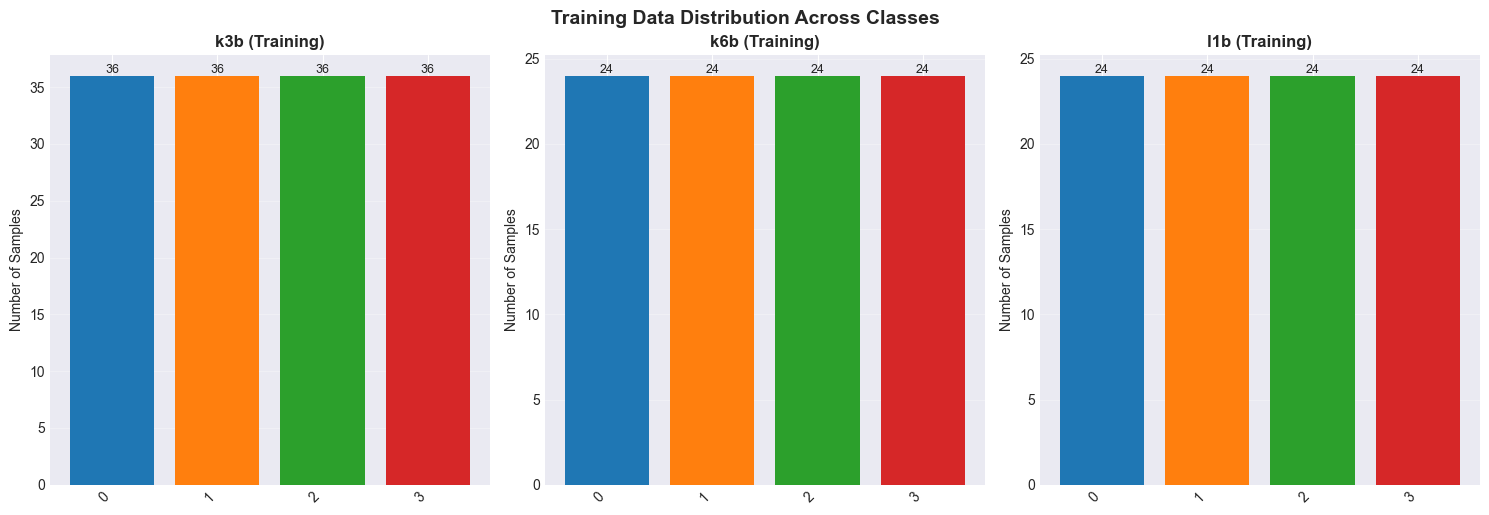

In [7]:
# Load all preprocessed data for visualization
class_names = config['preprocessing']['class_mapping']

if len(all_results) == 0:
    print("No data was preprocessed successfully. Please check the errors above.")
else:
    fig, axes = plt.subplots(1, len(all_results), figsize=(15, 5))
    if len(all_results) == 1:
        axes = [axes]

    for idx, result in enumerate(all_results):
        subject_id = result['subject_id']
        
        # Load training data
        train_file = processed_dir / f"{subject_id}_train.npz"
        if train_file.exists():
            data = np.load(train_file)
            y_train = data['y']
            
            # Count samples per class
            unique, counts = np.unique(y_train, return_counts=True)
            class_counts = [0] * len(class_names)
            for cls, count in zip(unique, counts):
                class_counts[cls] = count
            
            # Plot
            bars = axes[idx].bar(range(len(class_names)), class_counts,
                                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
            axes[idx].set_xticks(range(len(class_names)))
            axes[idx].set_xticklabels(class_names, rotation=45, ha='right')
            axes[idx].set_ylabel('Number of Samples', fontsize=10)
            axes[idx].set_title(f'{subject_id} (Training)', fontsize=12, fontweight='bold')
            axes[idx].grid(axis='y', alpha=0.3)
            
            # Add count labels
            for bar, count in zip(bars, class_counts):
                if count > 0:
                    height = bar.get_height()
                    axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                                  f'{int(count)}',
                                  ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.suptitle('Training Data Distribution Across Classes', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.show()

## 7. Verify Saved Files

In [8]:
# List all saved files
print("\nSaved preprocessed files:")
print("-" * 60)

if processed_dir.exists():
    npz_files = sorted(processed_dir.glob("*.npz"))
    
    if npz_files:
        for npz_file in npz_files:
            file_size_mb = npz_file.stat().st_size / (1024 * 1024)
            print(f"  {npz_file.name:<25} ({file_size_mb:.2f} MB)")
        print("-" * 60)
        print(f"Total files: {len(npz_files)}")
    else:
        print("  No .npz files found")
else:
    print(f"  Processed data directory does not exist: {processed_dir}")


Saved preprocessed files:
------------------------------------------------------------
  k3b_train.npz             (63.99 MB)
  k3b_val.npz               (16.00 MB)
  k6b_train.npz             (42.68 MB)
  k6b_val.npz               (10.67 MB)
  l1b_train.npz             (42.68 MB)
  l1b_val.npz               (10.67 MB)
------------------------------------------------------------
Total files: 6


## 8. Summary

Data preprocessing complete. The following files have been created:
- Training data: `*_train.npz` (80% of data)
- Validation data: `*_val.npz` (20% of data)

Each file contains:
- `X`: EEG epoch data (n_samples, n_channels, n_timepoints)
- `y`: Class labels (0: left, 1: right, 2: down, 3: up)
- `sfreq`: Sampling frequency

**Next step**: Explore the preprocessed data using `01_data_exploration.ipynb`